# Data Loading

In [2]:
!pip install -q gdown

In [3]:
!gdown "https://drive.google.com/uc?id=1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS" -O /content/EyeDiseaseDataset.zip

Downloading...
From (original): https://drive.google.com/uc?id=1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS
From (redirected): https://drive.google.com/uc?id=1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS&confirm=t&uuid=236ddb57-ac8d-4b0b-9c2d-7f4d473a260c
To: /content/EyeDiseaseDataset.zip
100%|███████████████████████████████████████| 4.08G/4.08G [00:34<00:00, 117MB/s]


In [4]:
import zipfile
import os

zip_path = "/content/EyeDiseaseDataset.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


In [5]:
import os

print(os.path.exists("/content/EyeDiseaseDataset.zip"))
print(os.listdir("/content")[:30])

True
['.config', 'Tasks_and_Classes.md', 'images', 'EyeDiseaseDataset.zip', 'metadata.csv', 'splits', 'catalog', 'sample_data']


In [6]:
import os

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

image_files = []

for root, dirs, files in os.walk("/content/images"):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_files.append(os.path.join(root, file))

print("Actual image files:", len(image_files))

Actual image files: 11839


# Data Explorartion

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
DATASET_PATH = "/content"
metadata_path = os.path.join(DATASET_PATH, "metadata.csv")
images_path = os.path.join(DATASET_PATH, "images")
df = pd.read_csv(metadata_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (11839, 4)

Columns:
['filename', 'dataset', 'unified_label', 'original_label']

First 5 rows:


,filename,dataset,unified_label,original_label
0,ACRIMA_Im001_ACRIMA.jpg,ACRIMA,Normal,Normal
1,ACRIMA_Im002_ACRIMA.jpg,ACRIMA,Normal,Normal
2,ACRIMA_Im003_ACRIMA.jpg,ACRIMA,Normal,Normal
3,ACRIMA_Im004_ACRIMA.jpg,ACRIMA,Normal,Normal
4,ACRIMA_Im005_ACRIMA.jpg,ACRIMA,Normal,Normal


In [10]:
# explore class distribution
class_counts = df["unified_label"].value_counts()
print("Class distribution:")
print(class_counts)

Class distribution:
unified_label
Normal                  4698
Diabetic Retinopathy    4113
Others                  1102
Glaucoma                 930
Cataract                 340
Myopia                   294
AMD                      274
Hypertension              88
Name: count, dtype: int64


In [11]:
class_percentages = (
    df["unified_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Class percentages:")
print(class_percentages)

Class percentages:
unified_label
Normal                  39.68
Diabetic Retinopathy    34.74
Others                   9.31
Glaucoma                 7.86
Cataract                 2.87
Myopia                   2.48
AMD                      2.31
Hypertension             0.74
Name: proportion, dtype: float64


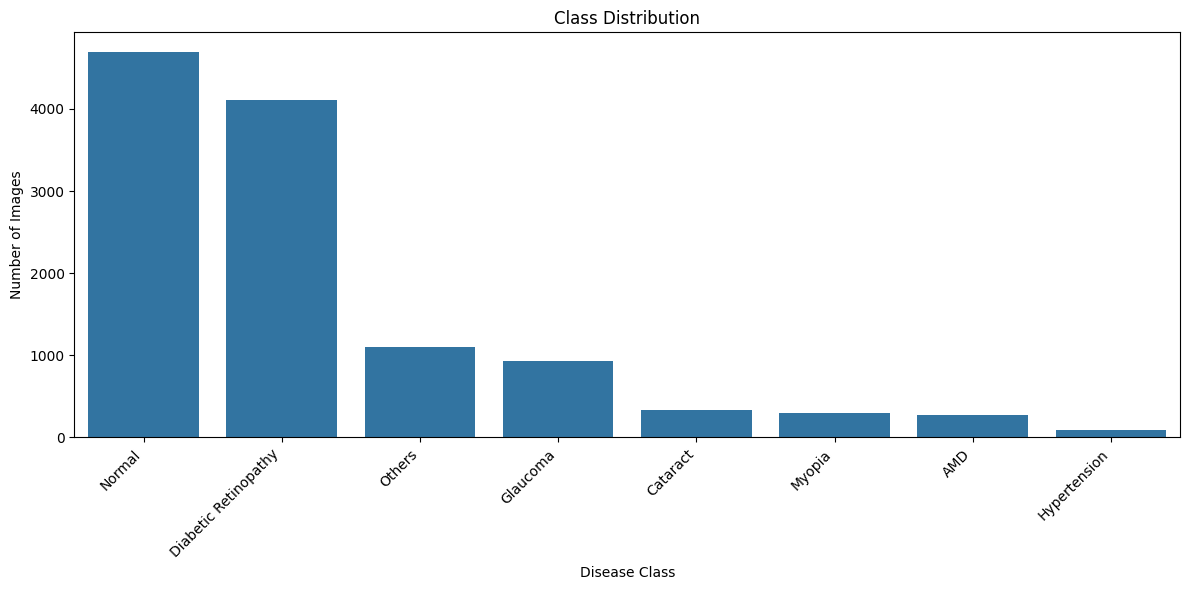

In [12]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

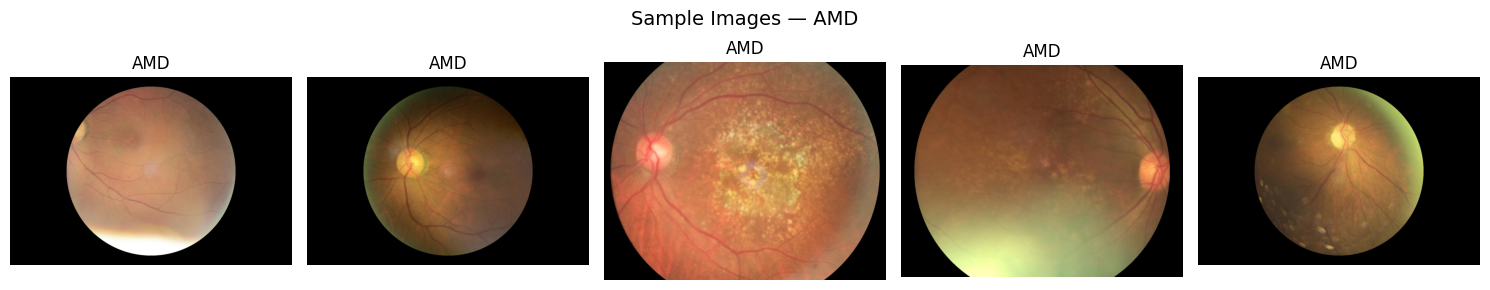

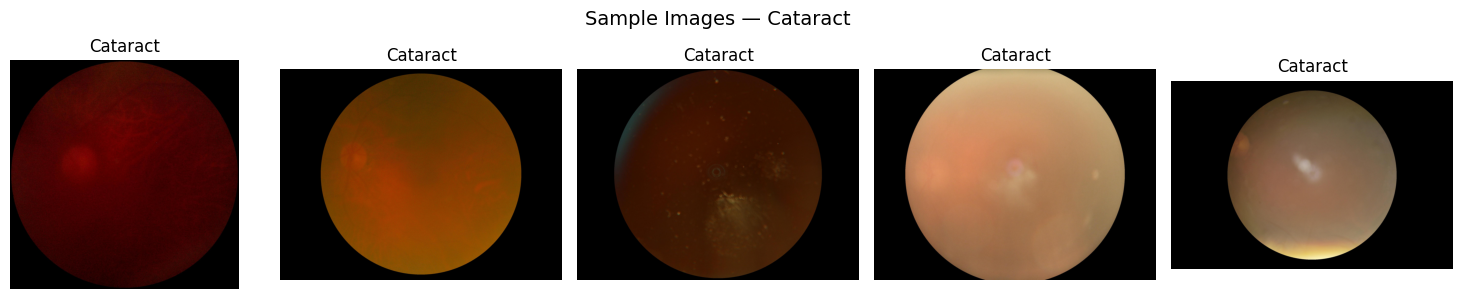

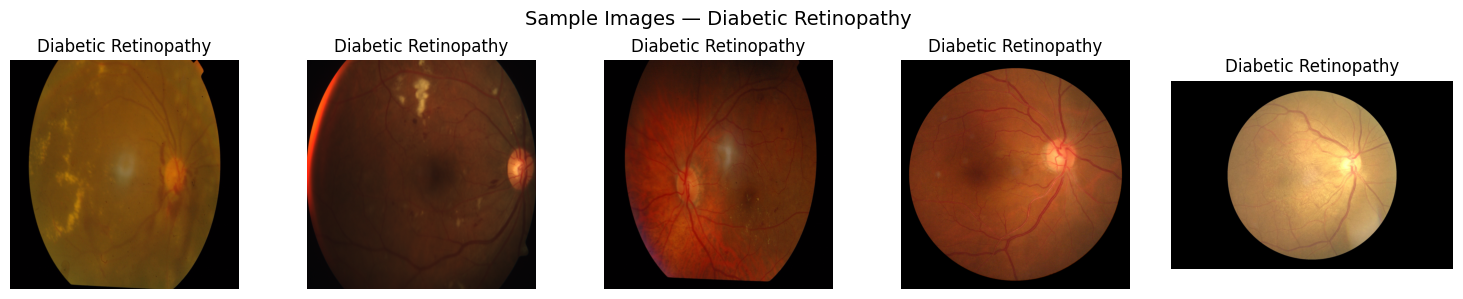

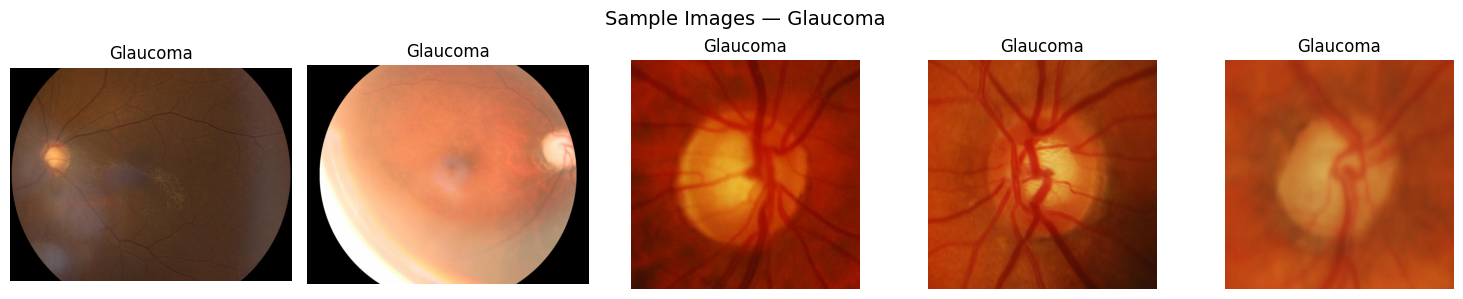

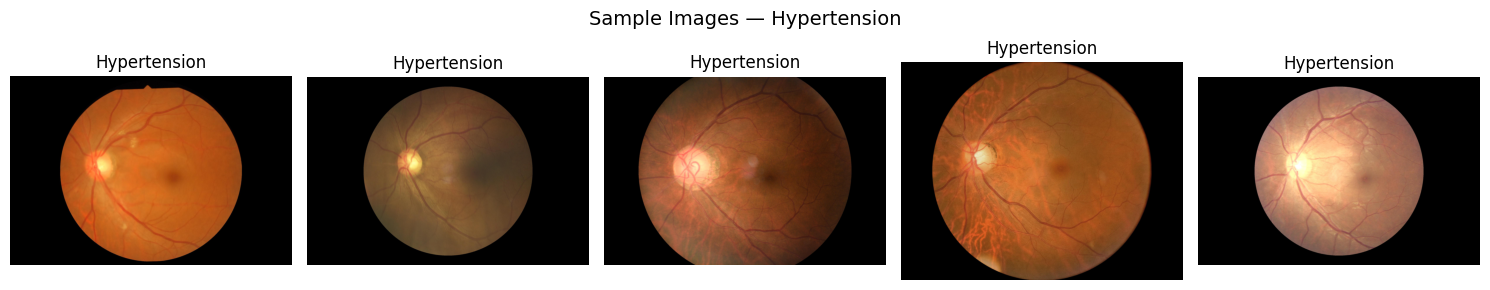

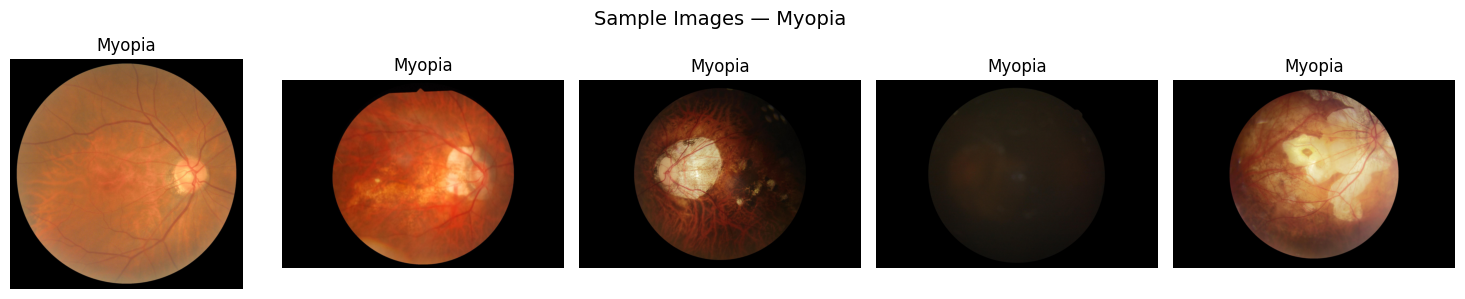

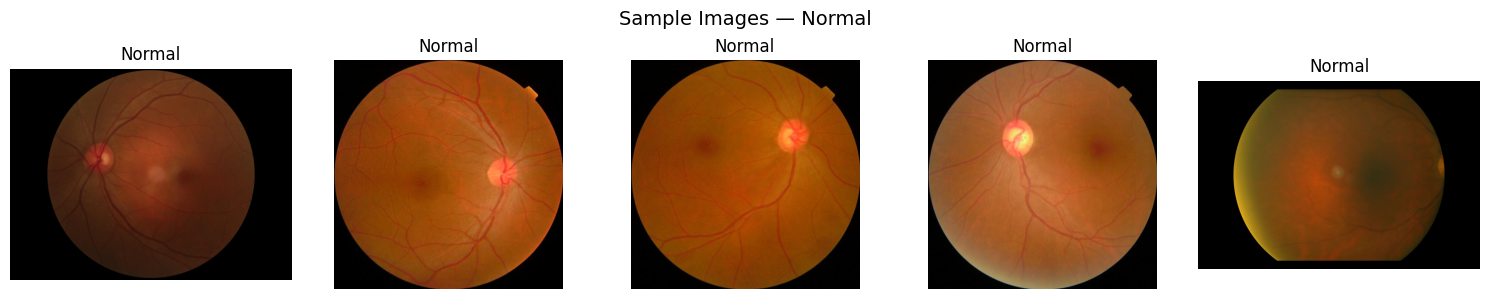

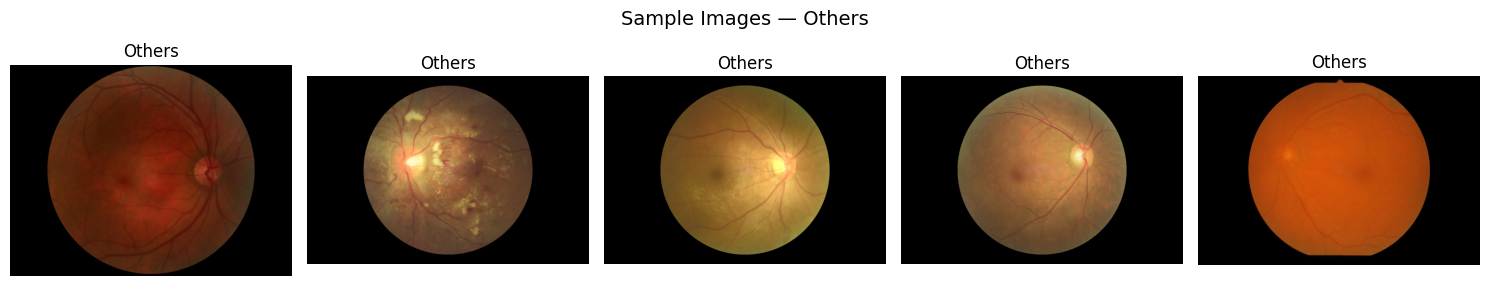

In [13]:
# sample images from every class

from PIL import Image
classes = sorted(df["unified_label"].unique())
for class_name in classes:
    class_df = df[df["unified_label"] == class_name]
    samples = class_df.sample(
        n=5,
        random_state=42
    )

    plt.figure(figsize=(15, 3))

    for i, (_, row) in enumerate(samples.iterrows()):
        image_path = os.path.join( images_path, row["filename"])
        img = Image.open(image_path).convert("RGB")
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(class_name)

    plt.suptitle(
        f"Sample Images — {class_name}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

In [14]:
# Check image dimensions and formats

image_info = []
for _, row in df.iterrows():
    image_path = os.path.join(
        images_path,
        row["filename"]
    )

    img = Image.open(image_path)
    image_info.append({
        "filename": row["filename"],
        "class": row["unified_label"],
        "width": img.width,
        "height": img.height,
        "mode": img.mode
    })

image_info_df = pd.DataFrame(image_info)
display(image_info_df.head())

,filename,class,width,height,mode
0,ACRIMA_Im001_ACRIMA.jpg,Normal,349,349,RGB
1,ACRIMA_Im002_ACRIMA.jpg,Normal,277,277,RGB
2,ACRIMA_Im003_ACRIMA.jpg,Normal,409,409,RGB
3,ACRIMA_Im004_ACRIMA.jpg,Normal,406,406,RGB
4,ACRIMA_Im005_ACRIMA.jpg,Normal,316,316,RGB


In [15]:
print("Image modes:")
print(image_info_df["mode"].value_counts())

print("\nWidth statistics:")
print(image_info_df["width"].describe())

print("\nHeight statistics:")
print(image_info_df["height"].describe())

print(
    "\nNumber of unique dimensions:",
    image_info_df[["width", "height"]]
    .drop_duplicates()
    .shape[0]
)

Image modes:
mode
RGB    11839
Name: count, dtype: int64

Width statistics:
count    11839.000000
mean      1804.145789
std        942.329905
min        178.000000
25%       1000.000000
50%       1936.000000
75%       2592.000000
max       5184.000000
Name: width, dtype: float64

Height statistics:
count    11839.000000
mean      1415.201960
std        602.068855
min        178.000000
25%       1000.000000
50%       1444.000000
75%       1728.000000
max       3456.000000
Name: height, dtype: float64

Number of unique dimensions: 465


In [16]:
## Analyze black pixels / black boundaries

from PIL import Image
black_info = []

for _, row in df.iterrows():
    image_path = os.path.join(
        images_path,
        row["filename"]
    )

    img = Image.open(image_path).convert("RGB")
    img.thumbnail((256, 256))
    img = np.array(img)
    black_pixels = np.all(img < 10, axis=2)
    black_percentage = black_pixels.mean() * 100
    black_info.append({
        "filename": row["filename"],
        "class": row["unified_label"],
        "black_percentage": black_percentage
    })

black_df = pd.DataFrame(black_info)
print("Average black pixel percentage:", black_df["black_percentage"].mean())
print("Median black pixel percentage:", black_df["black_percentage"].median())
print("Maximum black pixel percentage:", black_df["black_percentage"].max())

Average black pixel percentage: 33.40234634995906
Median black pixel percentage: 29.065279150197625
Maximum black pixel percentage: 77.008056640625


In [17]:
## images with the most black pixels
top_black = black_df.sort_values("black_percentage",ascending=False).head(10)
display(top_black)

,filename,class,black_percentage
8028,ODIR_2133_right.jpg,Cataract,77.008057
8029,ODIR_2134_left.jpg,Cataract,74.698893
7119,ODIR_1209_left.jpg,Glaucoma,70.294189
10672,ODIR_4038_right.jpg,Diabetic Retinopathy,69.525146
8937,ODIR_2672_left.jpg,Normal,66.414332
7454,ODIR_1465_right.jpg,Glaucoma,66.411638
7453,ODIR_1465_left.jpg,Glaucoma,66.306573
8938,ODIR_2672_right.jpg,Normal,66.303879
9925,ODIR_3166_left.jpg,Normal,66.303879
5235,ODIR_199_left.jpg,Diabetic Retinopathy,66.274246


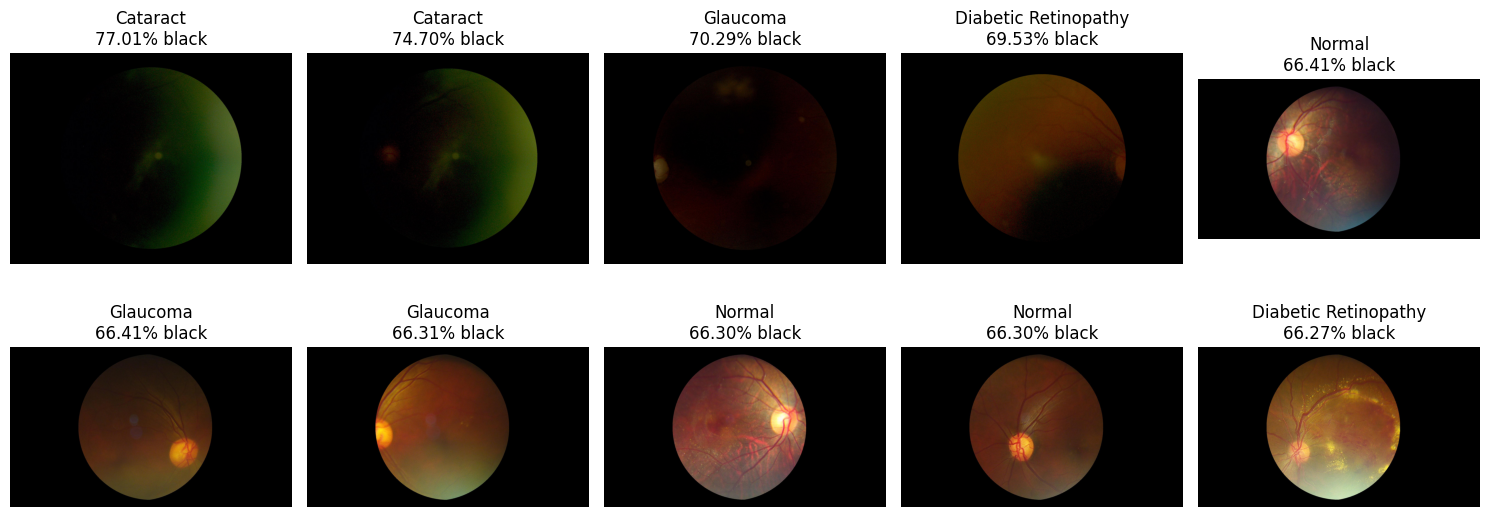

In [18]:
plt.figure(figsize=(15, 6))

for i, (_, row) in enumerate(top_black.iterrows()):
    image_path = os.path.join( images_path, row["filename"])
    img = Image.open(image_path).convert("RGB")
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"{row['class']}\n"
        f"{row['black_percentage']:.2f}% black"
    )

plt.tight_layout()
plt.show()

In [19]:
def remove_black_border(img, threshold=10):
    img_array = np.array(img)
    mask = np.any(img_array > threshold, axis=2)
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]

    if len(rows) == 0 or len(cols) == 0:
        return img

    cropped = img.crop((
        cols[0],
        rows[0],
        cols[-1] + 1,
        rows[-1] + 1
    ))

    return cropped

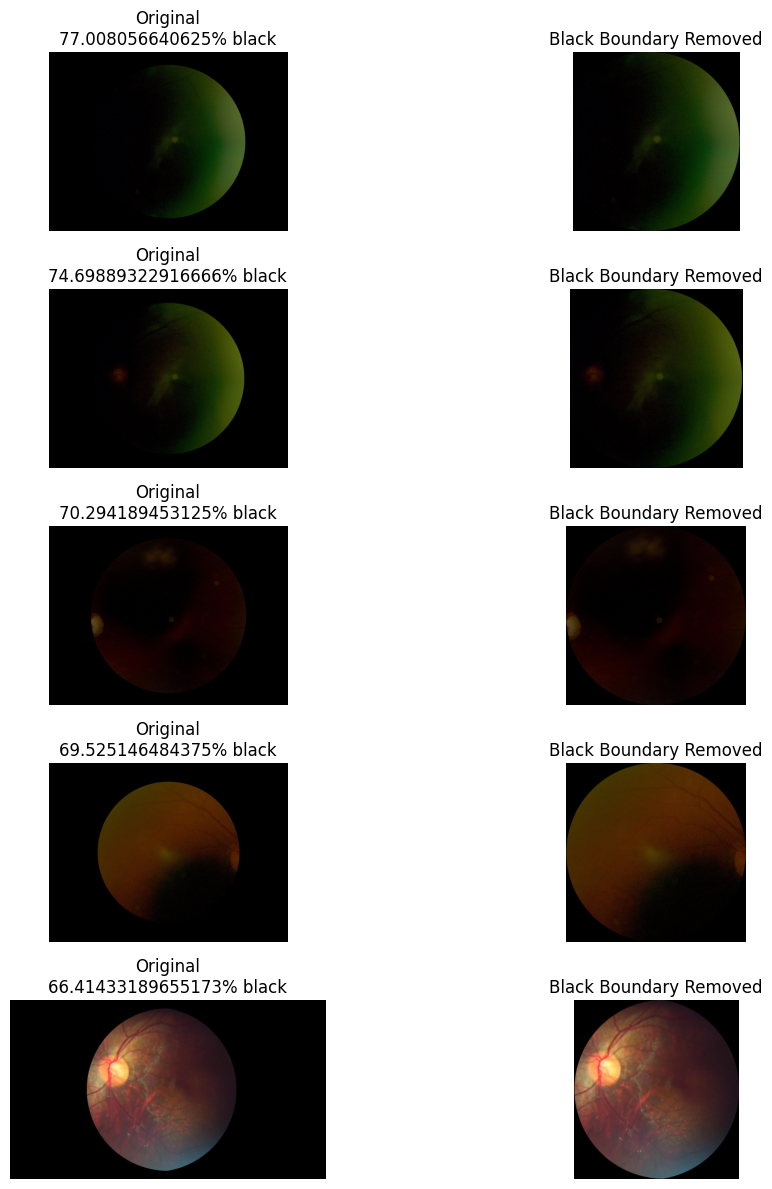

In [20]:
## compare original vs removing the black boundary

comparison_df = black_df.sort_values("black_percentage",ascending=False).head(5)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(comparison_df.iterrows()):
    image_path = os.path.join( images_path, row["filename"])
    original = Image.open( image_path).convert("RGB")
    cropped = remove_black_border(original)

    # Original
    plt.subplot(5, 2, 2*i + 1)
    plt.imshow(original)
    plt.axis("off")
    plt.title(f"Original\n{row['black_percentage']}% black")

    # Cropped
    plt.subplot(5, 2, 2*i + 2)
    plt.imshow(cropped)
    plt.axis("off")
    plt.title("Black Boundary Removed")

plt.tight_layout()
plt.show()

In [21]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder

SEED = 42
IMG_SIZE = 320
BATCH_SIZE = 32

tf.keras.utils.set_random_seed(SEED)
df = df.copy()
label_encoder = LabelEncoder()

df["y"] = label_encoder.fit_transform(df["unified_label"])
df["src"] = df["filename"].apply(lambda x: os.path.join(images_path, x))
df["group"] = df["filename"].str.extract(r"^(ODIR_\d+)")[0]
df["group"] = df["group"].fillna(df["filename"])

CLASSES = label_encoder.classes_

print("Classes:")
print(CLASSES)
print("\nNumber of images:", len(df))
print(
    "Number of patient groups:",
    df["group"].nunique()
)

Classes:
['AMD' 'Cataract' 'Diabetic Retinopathy' 'Glaucoma' 'Hypertension'
 'Myopia' 'Normal' 'Others']

Number of images: 11839
Number of patient groups: 8339


In [22]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(
    n_splits=7,
    shuffle=True,
    random_state=SEED
)

folds = [test_idx 
         for _, test_idx in sgkf.split(df,df["y"], df["group"])]

test_idx = folds[0]
val_idx = folds[1]
train_idx = np.setdiff1d(df.index, np.concatenate([test_idx, val_idx]))

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Train: 8459
Validation: 1691
Test: 1689


In [23]:
train_groups = set(df.loc[train_idx, "group"])
val_groups = set(df.loc[val_idx, "group"])
test_groups = set(df.loc[test_idx, "group"])

print("Train ∩ Validation:",len(train_groups & val_groups))
print("Train ∩ Test:",len(train_groups & test_groups))
print("Validation ∩ Test:",len(val_groups & test_groups))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [24]:
split_distribution = pd.DataFrame({
    "Train": df.loc[train_idx, "unified_label"].value_counts(),
    "Validation": df.loc[val_idx, "unified_label"].value_counts(),
    "Test": df.loc[test_idx, "unified_label"].value_counts()
}).fillna(0).astype(int)

print(split_distribution)

                      Train  Validation  Test
unified_label                                
AMD                     192          52    30
Cataract                244          42    54
Diabetic Retinopathy   2945         585   583
Glaucoma                663         117   150
Hypertension             52          20    16
Myopia                  198          48    48
Normal                 3355         669   674
Others                  810         158   134


In [25]:
train_counts = np.bincount(df.loc[train_idx, "y"], minlength=len(CLASSES))
class_weights = (train_counts.sum()/ (len(CLASSES) * train_counts)) ** 0.5
CLASS_WEIGHT = {
    i: float(class_weights[i])
    for i in range(len(CLASSES))
}

print("Class weights:\n")

for i, class_name in enumerate(CLASSES):
    print(
        f"{class_name:25s}: "
        f"{CLASS_WEIGHT[i]:.4f}"
    )

Class weights:

AMD                      : 2.3467
Cataract                 : 2.0817
Diabetic Retinopathy     : 0.5992
Glaucoma                 : 1.2629
Hypertension             : 4.5093
Myopia                   : 2.3109
Normal                   : 0.5614
Others                   : 1.1425


In [26]:
RAW_DIR = "/content/preprocessed_raw"
CROP_DIR = "/content/preprocessed_crop"

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(CROP_DIR, exist_ok=True)

df["raw_path"] = df["filename"].apply(lambda x: os.path.join(RAW_DIR, os.path.splitext(x)[0] + ".jpg"))
df["crop_path"] = df["filename"].apply(lambda x: os.path.join(CROP_DIR,os.path.splitext(x)[0] + ".jpg"))
print(df[["filename", "raw_path", "crop_path"]].head())

                  filename                                           raw_path  \
0  ACRIMA_Im001_ACRIMA.jpg  /content/preprocessed_raw/ACRIMA_Im001_ACRIMA.jpg   
1  ACRIMA_Im002_ACRIMA.jpg  /content/preprocessed_raw/ACRIMA_Im002_ACRIMA.jpg   
2  ACRIMA_Im003_ACRIMA.jpg  /content/preprocessed_raw/ACRIMA_Im003_ACRIMA.jpg   
3  ACRIMA_Im004_ACRIMA.jpg  /content/preprocessed_raw/ACRIMA_Im004_ACRIMA.jpg   
4  ACRIMA_Im005_ACRIMA.jpg  /content/preprocessed_raw/ACRIMA_Im005_ACRIMA.jpg   

                                           crop_path  
0  /content/preprocessed_crop/ACRIMA_Im001_ACRIMA...  
1  /content/preprocessed_crop/ACRIMA_Im002_ACRIMA...  
2  /content/preprocessed_crop/ACRIMA_Im003_ACRIMA...  
3  /content/preprocessed_crop/ACRIMA_Im004_ACRIMA...  
4  /content/preprocessed_crop/ACRIMA_Im005_ACRIMA...  


In [27]:
## image preprocessing

from PIL import Image
def preprocess_image(src, dst, crop=False, threshold=15):
    if os.path.exists(dst):
        return
    img = Image.open(src).convert("RGB")
    
    if crop:
        arr = np.asarray(img)
        mask = arr.max(axis=2) > threshold
        if mask.any():
            rows = np.where(mask.any(axis=1))[0]
            cols = np.where(mask.any(axis=0))[0]
            img = img.crop((
                cols[0],
                rows[0],
                cols[-1] + 1,
                rows[-1] + 1
            ))

    w, h = img.size
    size = max(w, h)

    canvas = Image.new("RGB",(size, size),(0, 0, 0))
    canvas.paste(img,((size - w) // 2,(size - h) // 2))
    img = canvas.resize((IMG_SIZE, IMG_SIZE),Image.Resampling.LANCZOS)
    img.save(dst, quality=95)

In [28]:
from tqdm.auto import tqdm
for _, row in tqdm(df.iterrows(), total=len(df)):
    preprocess_image(row["src"],row["raw_path"],crop=False)
    preprocess_image(row["src"],row["crop_path"],crop=True)
    
print("Finished preprocessing!")

  0%|          | 0/11839 [00:00<?, ?it/s]

Finished preprocessing!


In [30]:
from tensorflow.keras import layers

AUGMENTATION = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08,fill_mode="constant"),
    layers.RandomZoom(0.10,fill_mode="constant"),
    layers.RandomContrast(0.10)
])

I0000 00:00:1790322723.972192      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790322723.975177      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [31]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image,channels=3)
    image = tf.ensure_shape(image,[IMG_SIZE, IMG_SIZE, 3])
    image = tf.cast(image,tf.float32)
    return image, label

In [32]:
def make_dataset(dataframe,path_column,training=False):
    paths = dataframe[path_column].values
    labels = dataframe["y"].values
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        dataset = dataset.shuffle(len(dataframe),seed=SEED)
    dataset = dataset.map(load_image,num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        dataset = dataset.map(lambda x, y: (AUGMENTATION(x,training=True),y),num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

In [33]:
## CNN from scratch 

from tensorflow.keras import models
def build_cnn():
    def conv_block(x, filters):
        x = layers.Conv2D(filters,3,padding="same",use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

        x = layers.Conv2D(filters,3,padding="same",use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)
        return x

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Rescaling(1 / 255.0)(inputs)

    for filters in [32, 64, 128, 256, 256]:
        x = conv_block(x,filters)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(len(CLASSES), activation="softmax")(x)
    
    return tf.keras.Model(inputs,outputs)

# EfficientNet

In [34]:
from tensorflow.keras.applications import EfficientNetB0

def build_transfer():
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE,IMG_SIZE,3)
    )

    base_model.trainable = False
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = base_model(inputs,training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(CLASSES),activation="softmax")(x)
    model = tf.keras.Model(inputs,outputs)

    return model, base_model

In [35]:
from sklearn.metrics import f1_score

class MacroF1(tf.keras.callbacks.Callback):
    def __init__(self,validation_dataset,y_true):
        super().__init__()
        self.validation_dataset = validation_dataset
        self.y_true = y_true

    def on_epoch_end(self,epoch,logs=None):
        logs = logs or {}
        predictions = self.model.predict(self.validation_dataset,verbose=0)
        predictions = np.argmax(predictions,axis=1)
        macro_f1 = f1_score(self.y_true,predictions,average="macro")
        logs["val_macro_f1"] = macro_f1
        print(f" - val_macro_f1: {macro_f1:.4f}")

In [36]:
def make_callbacks(validation_dataset,y_validation,patience=8):

    return [MacroF1(
            validation_dataset,
            y_validation
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor="val_macro_f1",
            mode="max",
            patience=patience,
            restore_best_weights=True
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_macro_f1",
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-7
        )
    ]

In [37]:
train_raw = make_dataset(
    df.loc[train_idx],"raw_path",training=True)

val_raw = make_dataset(df.loc[val_idx],"raw_path",training=False)
test_raw = make_dataset(df.loc[test_idx],"raw_path",training=False)
y_val = df.loc[val_idx,"y"].values
y_test = df.loc[test_idx,"y"].values
print("Raw datasets ready!")

Raw datasets ready!


In [38]:
cnn_raw = build_cnn()

cnn_raw.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn_raw = cnn_raw.fit(
    train_raw,
    validation_data=val_raw,
    epochs=40,
    class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks(
        val_raw,
        y_val
    ),
    verbose=1
)

Epoch 1/40


2026-09-25 07:52:28.022414: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 07:52:28.215347: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 07:52:29.184895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 07:52:29.355497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 07:52:31.646298: E external/local_xla/xla/stream_

265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.4176 - loss: 1.4219 - val_macro_f1: 0.1665
265/265 ━━━━━━━━━━━━━━━━━━━━ 151s 568ms/step - accuracy: 0.4262 - loss: 1.4048 - val_accuracy: 0.3306 - val_loss: 1.5232 - val_macro_f1: 0.1665 - learning_rate: 0.0010
Epoch 3/40
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.4498 - loss: 1.3548 - val_macro_f1: 0.2514
265/265 ━━━━━━━━━━━━━━━━━━━━ 151s 569ms/step - accuracy: 0.4467 - loss: 1.3715 - val_accuracy: 0.4707 - val_loss: 1.3761 - val_macro_f1: 0.2514 - learning_rate: 0.0010
Epoch 4/40
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.4532 - loss: 1.3367 - val_macro_f1: 0.2070
265/265 ━━━━━━━━━━━━━━━━━━━━ 150s 567ms/step - accuracy: 0.4557 - loss: 1.3451 - val_accuracy: 0.3365 - val_loss: 1.5906 - val_macro_f1: 0.2070 - learning_rate: 0.0010
Epoch 5/40
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.4639 - loss: 1.3000 - val_macro_f1: 0.1780
265/265 ━━━━━━━━━━━━━━━━━━━━ 151s 569ms/step - accuracy: 0.4599

In [39]:
from sklearn.metrics import classification_report

cnn_raw_probs = cnn_raw.predict(test_raw)
cnn_raw_pred = np.argmax(cnn_raw_probs,axis=1)
print(
    classification_report(
        y_test,
        cnn_raw_pred,
        target_names=CLASSES,
        digits=4
    )
)

53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 243ms/step
                      precision    recall  f1-score   support

                 AMD     0.0000    0.0000    0.0000        30
            Cataract     0.4737    0.6667    0.5538        54
Diabetic Retinopathy     0.6559    0.5918    0.6222       583
            Glaucoma     0.7500    0.4200    0.5385       150
        Hypertension     0.0000    0.0000    0.0000        16
              Myopia     0.6800    0.7083    0.6939        48
              Normal     0.6450    0.6632    0.6540       674
              Others     0.1653    0.3060    0.2147       134

            accuracy                         0.5719      1689
           macro avg     0.4212    0.4195    0.4096      1689
        weighted avg     0.5980    0.5719    0.5780      1689



In [40]:
transfer_raw, base_raw = build_transfer()

transfer_raw.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_transfer_raw_1 = transfer_raw.fit(
    train_raw,
    validation_data=val_raw,
    epochs=8,
    class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks(
        val_raw,
        y_val,
        patience=4
    ),
    verbose=1
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8


2026-09-25 09:30:35.519013: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:30:35.672741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:30:36.112238: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:30:36.254014: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:30:37.118504: E external/local_xla/xla/stream_

264/265 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.4616 - loss: 1.3001

2026-09-25 09:32:08.386536: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:32:08.524623: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:32:08.857041: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:32:08.999148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:32:09.844100: E external/local_xla/xla/stream_

265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.4619 - loss: 1.2997

2026-09-25 09:32:34.988611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:32:35.139367: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:32:35.528997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:32:35.671469: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:32:36.497944: E external/local_xla/xla/stream_

 - val_macro_f1: 0.4308
265/265 ━━━━━━━━━━━━━━━━━━━━ 166s 507ms/step - accuracy: 0.5164 - loss: 1.1805 - val_accuracy: 0.6174 - val_loss: 1.0619 - val_macro_f1: 0.4308 - learning_rate: 0.0010
Epoch 2/8
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.5792 - loss: 1.0530 - val_macro_f1: 0.4813
265/265 ━━━━━━━━━━━━━━━━━━━━ 84s 318ms/step - accuracy: 0.5903 - loss: 1.0062 - val_accuracy: 0.5991 - val_loss: 1.0144 - val_macro_f1: 0.4813 - learning_rate: 0.0010
Epoch 3/8
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.6021 - loss: 0.9395 - val_macro_f1: 0.5257
265/265 ━━━━━━━━━━━━━━━━━━━━ 84s 317ms/step - accuracy: 0.5963 - loss: 0.9659 - val_accuracy: 0.6227 - val_loss: 1.0093 - val_macro_f1: 0.5257 - learning_rate: 0.0010
Epoch 4/8
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.6131 - loss: 0.9238 - val_macro_f1: 0.5170
265/265 ━━━━━━━━━━━━━━━━━━━━ 85s 319ms/step - accuracy: 0.6037 - loss: 0.9450 - val_accuracy: 0.6487 - val_loss: 0.9736 - val_macro_f1: 0.5170 -

In [41]:
base_raw.trainable = True

for layer in base_raw.layers[:-60]:
    layer.trainable = False

for layer in base_raw.layers:
    if isinstance(layer,layers.BatchNormalization):
        layer.trainable = False

transfer_raw.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_transfer_raw_2 = transfer_raw.fit(
    train_raw,
    validation_data=val_raw,
    epochs=30,
    class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks(
        val_raw,
        y_val,
        patience=3
    ),
    verbose=1
)

Epoch 1/30


2026-09-25 09:43:08.125202: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:43:08.266878: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


264/265 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.6354 - loss: 0.8493

2026-09-25 09:44:40.693894: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:44:40.834427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:44:41.103740: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 09:44:41.245810: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6353 - loss: 0.8494 - val_macro_f1: 0.5426
265/265 ━━━━━━━━━━━━━━━━━━━━ 156s 478ms/step - accuracy: 0.6261 - loss: 0.8642 - val_accuracy: 0.6541 - val_loss: 0.9196 - val_macro_f1: 0.5426 - learning_rate: 1.0000e-05
Epoch 2/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.6327 - loss: 0.8675 - val_macro_f1: 0.5464
265/265 ━━━━━━━━━━━━━━━━━━━━ 87s 327ms/step - accuracy: 0.6362 - loss: 0.8515 - val_accuracy: 0.6458 - val_loss: 0.9249 - val_macro_f1: 0.5464 - learning_rate: 1.0000e-05
Epoch 3/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.6389 - loss: 0.8440 - val_macro_f1: 0.5560
265/265 ━━━━━━━━━━━━━━━━━━━━ 87s 327ms/step - accuracy: 0.6383 - loss: 0.8335 - val_accuracy: 0.6541 - val_loss: 0.9049 - val_macro_f1: 0.5560 - learning_rate: 1.0000e-05
Epoch 4/30
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.6313 - loss: 0.8478 - val_macro_f1: 0.5469
265/265 ━━━━━━━━━━━━━━━━━━━━ 87s 326ms/step - accurac

In [42]:
transfer_raw_probs = transfer_raw.predict(test_raw)
transfer_raw_pred = np.argmax(transfer_raw_probs,axis=1)

print(
    classification_report(
        y_test,
        transfer_raw_pred,
        target_names=CLASSES,
        digits=4
    )
)

52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

2026-09-25 10:09:37.683712: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 10:09:37.831461: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 10:09:38.215578: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 10:09:38.357054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 10:09:39.178789: E external/local_xla/xla/stream_

53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 307ms/step
                      precision    recall  f1-score   support

                 AMD     0.2000    0.3000    0.2400        30
            Cataract     0.5522    0.6852    0.6116        54
Diabetic Retinopathy     0.7622    0.6432    0.6977       583
            Glaucoma     0.6154    0.6400    0.6275       150
        Hypertension     0.1600    0.2500    0.1951        16
              Myopia     0.8684    0.6875    0.7674        48
              Normal     0.6843    0.7300    0.7064       674
              Others     0.1837    0.2015    0.1922       134

            accuracy                         0.6353      1689
           macro avg     0.5033    0.5172    0.5047      1689
        weighted avg     0.6528    0.6353    0.6412      1689



# EfficientNet – Cropped

In [43]:
train_crop = make_dataset(
    df.loc[train_idx],
    "crop_path",
    training=True
)

val_crop = make_dataset(
    df.loc[val_idx],
    "crop_path",
    training=False
)

test_crop = make_dataset(
    df.loc[test_idx],
    "crop_path",
    training=False
)

print("Cropped datasets ready")

Cropped datasets ready!


In [44]:
cnn_crop = build_cnn()

cnn_crop.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn_crop = cnn_crop.fit(
    train_crop,
    validation_data=val_crop,
    epochs=40,
    class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks(
        val_crop,
        y_val
    ),
    verbose=1
)

Epoch 1/40
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.3558 - loss: 1.6144 - val_macro_f1: 0.1230
265/265 ━━━━━━━━━━━━━━━━━━━━ 170s 600ms/step - accuracy: 0.3756 - loss: 1.5207 - val_accuracy: 0.3791 - val_loss: 1.7630 - val_macro_f1: 0.1230 - learning_rate: 0.0010
Epoch 2/40
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.4113 - loss: 1.4336 - val_macro_f1: 0.1437
265/265 ━━━━━━━━━━━━━━━━━━━━ 152s 575ms/step - accuracy: 0.4240 - loss: 1.4063 - val_accuracy: 0.3862 - val_loss: 1.5635 - val_macro_f1: 0.1437 - learning_rate: 0.0010
Epoch 3/40
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.4328 - loss: 1.3306 - val_macro_f1: 0.2700
265/265 ━━━━━━━━━━━━━━━━━━━━ 152s 574ms/step - accuracy: 0.4327 - loss: 1.3226 - val_accuracy: 0.4293 - val_loss: 1.3272 - val_macro_f1: 0.2700 - learning_rate: 0.0010
Epoch 4/40
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.4537 - loss: 1.2684 - val_macro_f1: 0.3019
265/265 ━━━━━━━━━━━━━━━━━━━━ 153s 577ms/step - accur

In [45]:
cnn_crop_probs = cnn_crop.predict(test_crop)
cnn_crop_pred = np.argmax(cnn_crop_probs,axis=1)

print(
    classification_report(
        y_test,
        cnn_crop_pred,
        target_names=CLASSES,
        digits=4
    )
)

53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step
                      precision    recall  f1-score   support

                 AMD     0.2083    0.1667    0.1852        30
            Cataract     0.4750    0.7037    0.5672        54
Diabetic Retinopathy     0.9314    0.4425    0.6000       583
            Glaucoma     0.7320    0.4733    0.5749       150
        Hypertension     0.0455    0.2500    0.0769        16
              Myopia     0.7778    0.7292    0.7527        48
              Normal     0.7041    0.7166    0.7103       674
              Others     0.1862    0.5448    0.2776       134

            accuracy                         0.5725      1689
           macro avg     0.5075    0.5034    0.4681      1689
        weighted avg     0.7237    0.5725    0.6072      1689



In [48]:
transfer_crop, base_crop = build_transfer()

transfer_crop.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_transfer_crop_1 = transfer_crop.fit(
    train_crop,
    validation_data=val_crop,
    epochs=8,
    class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks(
        val_crop,
        y_val,
        patience=4
    ),
    verbose=1
)

Epoch 1/8
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.4772 - loss: 1.3275 - val_macro_f1: 0.4362
265/265 ━━━━━━━━━━━━━━━━━━━━ 142s 455ms/step - accuracy: 0.5362 - loss: 1.1937 - val_accuracy: 0.6085 - val_loss: 1.1077 - val_macro_f1: 0.4362 - learning_rate: 0.0010
Epoch 2/8
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.5875 - loss: 1.0565 - val_macro_f1: 0.4626
265/265 ━━━━━━━━━━━━━━━━━━━━ 85s 320ms/step - accuracy: 0.5965 - loss: 1.0055 - val_accuracy: 0.6050 - val_loss: 1.0422 - val_macro_f1: 0.4626 - learning_rate: 0.0010
Epoch 3/8
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.6058 - loss: 0.9542 - val_macro_f1: 0.5191
265/265 ━━━━━━━━━━━━━━━━━━━━ 85s 319ms/step - accuracy: 0.6063 - loss: 0.9677 - val_accuracy: 0.6404 - val_loss: 0.9956 - val_macro_f1: 0.5191 - learning_rate: 0.0010
Epoch 4/8
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.6205 - loss: 0.9152 - val_macro_f1: 0.4748
265/265 ━━━━━━━━━━━━━━━━━━━━ 85s 320ms/step - accuracy: 0.

In [49]:
# fine-tune efficientnet

base_crop.trainable = True
for layer in base_crop.layers[:-60]:
    layer.trainable = False

for layer in base_crop.layers:
    if isinstance(layer,layers.BatchNormalization):
        layer.trainable = False

transfer_crop.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_transfer_crop_2 = transfer_crop.fit(
    train_crop,
    validation_data=val_crop,
    epochs=20,
    class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks(
        val_crop,
        y_val,
        patience=3
    ),
    verbose=1
)

Epoch 1/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.6230 - loss: 0.9131 - val_macro_f1: 0.4999
265/265 ━━━━━━━━━━━━━━━━━━━━ 154s 477ms/step - accuracy: 0.6166 - loss: 0.9175 - val_accuracy: 0.6446 - val_loss: 0.9497 - val_macro_f1: 0.4999 - learning_rate: 1.0000e-05
Epoch 2/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.6387 - loss: 0.8793 - val_macro_f1: 0.5021
265/265 ━━━━━━━━━━━━━━━━━━━━ 87s 326ms/step - accuracy: 0.6323 - loss: 0.8932 - val_accuracy: 0.6452 - val_loss: 0.9371 - val_macro_f1: 0.5021 - learning_rate: 1.0000e-05
Epoch 3/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.6234 - loss: 0.8898 - val_macro_f1: 0.5151
265/265 ━━━━━━━━━━━━━━━━━━━━ 87s 327ms/step - accuracy: 0.6318 - loss: 0.8753 - val_accuracy: 0.6617 - val_loss: 0.8993 - val_macro_f1: 0.5151 - learning_rate: 1.0000e-05
Epoch 4/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.6339 - loss: 0.8767 - val_macro_f1: 0.5174
265/265 ━━━━━━━━━━━━━━━━━━━━ 87s 326ms/ste

In [50]:
transfer_crop_probs = transfer_crop.predict(test_crop)
transfer_crop_pred = np.argmax(transfer_crop_probs,axis=1)

print(
    classification_report(
        y_test,
        transfer_crop_pred,
        target_names=CLASSES,
        digits=4
    )
)

53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step
                      precision    recall  f1-score   support

                 AMD     0.3478    0.2667    0.3019        30
            Cataract     0.5139    0.6852    0.5873        54
Diabetic Retinopathy     0.6563    0.7599    0.7043       583
            Glaucoma     0.6438    0.6267    0.6351       150
        Hypertension     0.1905    0.2500    0.2162        16
              Myopia     0.9167    0.6875    0.7857        48
              Normal     0.7357    0.6855    0.7097       674
              Others     0.1932    0.1269    0.1532       134

            accuracy                         0.6501      1689
           macro avg     0.5247    0.5110    0.5117      1689
        weighted avg     0.6431    0.6501    0.6434      1689



In [51]:
#final comparision

from sklearn.metrics import precision_score, recall_score, f1_score

results = []

models_predictions = {
    "CNN - Raw": cnn_raw_pred,
    "CNN - Cropped": cnn_crop_pred,
    "EfficientNet - Raw": transfer_raw_pred,
    "EfficientNet - Cropped": transfer_crop_pred
}

for model_name, predictions in models_predictions.items():

    results.append({
        "Model": model_name,

        "Precision": precision_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

print(
    results_df.to_string(
        index=False
    )
)

                 Model  Precision   Recall       F1
             CNN - Raw   0.421240 0.419493 0.409627
         CNN - Cropped   0.507530 0.503350 0.468090
    EfficientNet - Raw   0.503275 0.517172 0.504727
EfficientNet - Cropped   0.524730 0.511026 0.511672


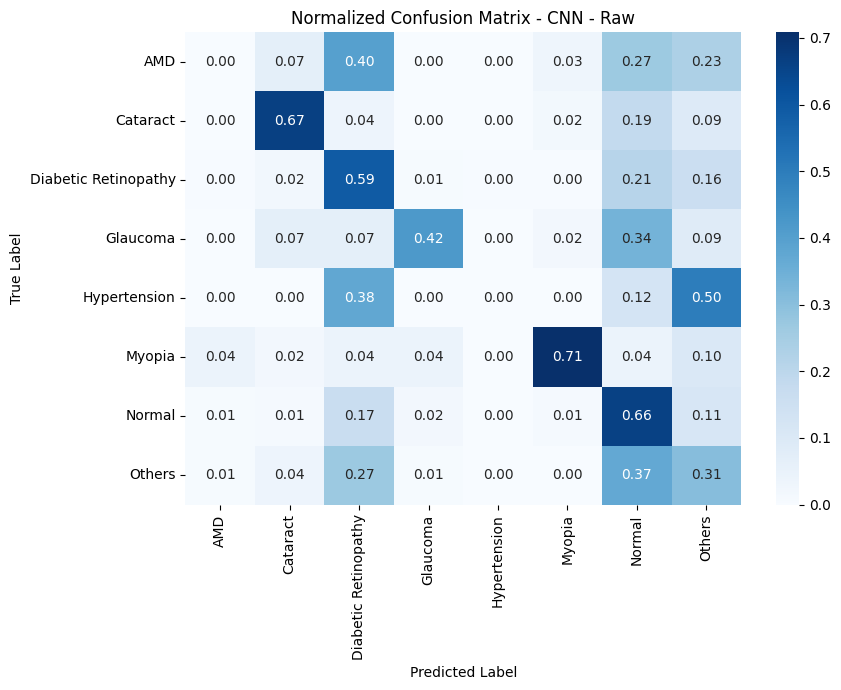

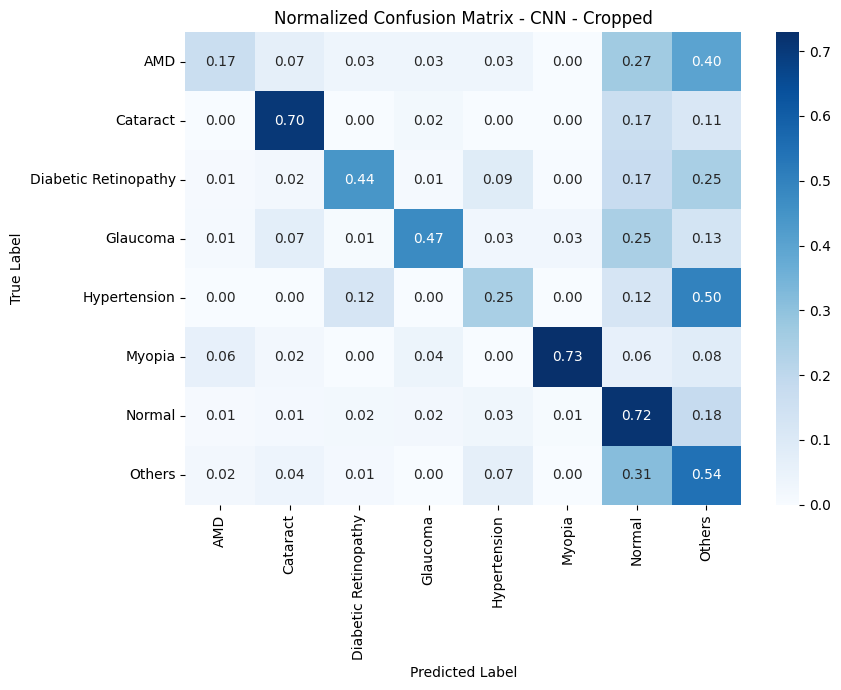

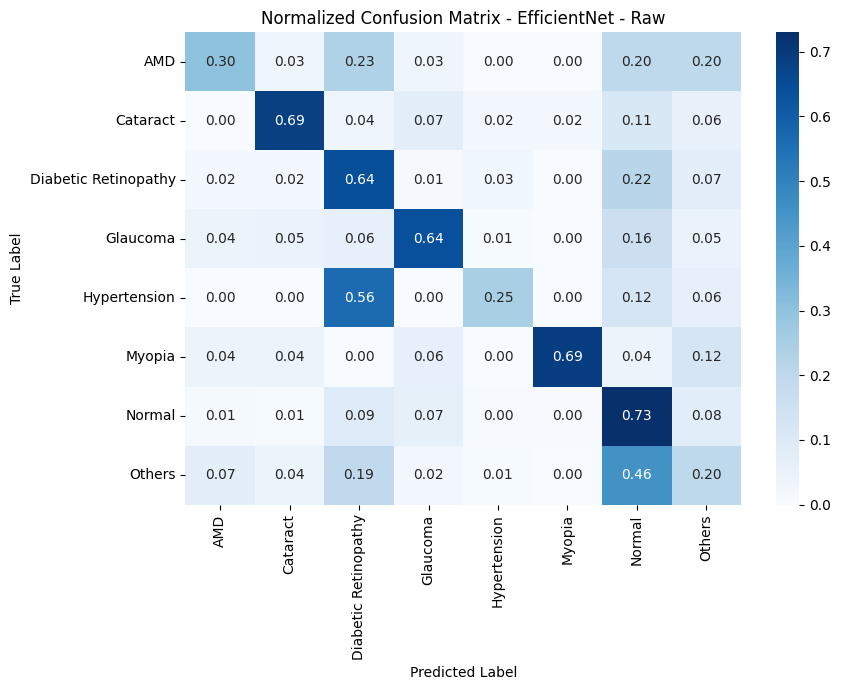

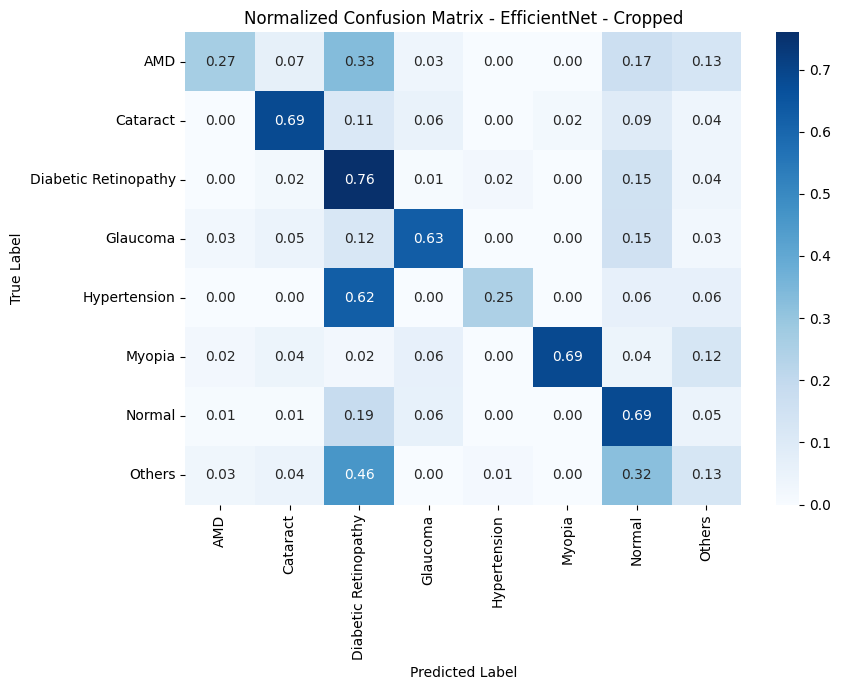

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt 

for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions,
        normalize="true"
    )

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=CLASSES,
        yticklabels=CLASSES
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(
        f"Normalized Confusion Matrix - {model_name}"
    )

    plt.tight_layout()
    plt.show()

In [54]:
others_df = df[df["unified_label"] == "Others"]
print(others_df["original_label"].value_counts())
print("\nSource datasets:")
print(others_df["dataset"].value_counts())

original_label
O    1102
Name: count, dtype: int64

Source datasets:
dataset
ODIR5K    1102
Name: count, dtype: int64


In [55]:
labels_per_group = df.groupby("group")["unified_label"].nunique()
multi_label_groups = labels_per_group[labels_per_group > 1]
print(f"Patient groups with >1 distinct label: {len(multi_label_groups)} / {df['group'].nunique()}")
print((len(multi_label_groups) / df['group'].nunique() * 100).__round__(2), "% of groups")

Patient groups with >1 distinct label: 0 / 8339
0.0 % of groups


In [56]:
def sparse_categorical_focal_loss(gamma=2.0, class_weight=None):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true_onehot = tf.one_hot(y_true, depth=y_pred.shape[-1])
        pt = tf.reduce_sum(y_true_onehot * y_pred, axis=-1)
        ce = -tf.math.log(pt)
        focal_weight = tf.pow(1.0 - pt, gamma)
        loss = focal_weight * ce
        if class_weight is not None:
            weights_tensor = tf.constant([class_weight[i] for i in range(len(class_weight))], dtype=tf.float32)
            sample_weights = tf.gather(weights_tensor, y_true)
            loss = loss * sample_weights
        return tf.reduce_mean(loss)
    return loss_fn

In [61]:
transfer_crop.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=sparse_categorical_focal_loss(
        gamma=2.0,
        class_weight=CLASS_WEIGHT
    ),
    metrics=["accuracy"]
)

history_transfer_crop_2 = transfer_crop.fit(
    train_crop,
    validation_data=val_crop,
    epochs=20,
    callbacks=make_callbacks(
        val_crop,
        y_val,
        patience=3
    ),
    verbose=1
)

Epoch 1/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.6303 - loss: 0.5129 - val_macro_f1: 0.5119
265/265 ━━━━━━━━━━━━━━━━━━━━ 146s 463ms/step - accuracy: 0.6230 - loss: 0.5335 - val_accuracy: 0.6458 - val_loss: 0.6042 - val_macro_f1: 0.5119 - learning_rate: 0.0010
Epoch 2/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.6205 - loss: 0.5261 - val_macro_f1: 0.5268
265/265 ━━━━━━━━━━━━━━━━━━━━ 89s 334ms/step - accuracy: 0.6189 - loss: 0.5332 - val_accuracy: 0.6079 - val_loss: 0.6121 - val_macro_f1: 0.5268 - learning_rate: 0.0010
Epoch 3/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.6243 - loss: 0.5321 - val_macro_f1: 0.5111
265/265 ━━━━━━━━━━━━━━━━━━━━ 84s 317ms/step - accuracy: 0.6202 - loss: 0.5296 - val_accuracy: 0.6375 - val_loss: 0.6203 - val_macro_f1: 0.5111 - learning_rate: 0.0010
Epoch 4/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.6231 - loss: 0.5097 - val_macro_f1: 0.5195
265/265 ━━━━━━━━━━━━━━━━━━━━ 84s 317ms/step - accuracy

In [62]:
y_test_pred_prob = transfer_crop.predict(test_crop)
y_test_pred = np.argmax(y_test_pred_prob,axis=1)

53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step


In [64]:
class_names = [
    "AMD",
    "Cataract",
    "Diabetic Retinopathy",
    "Glaucoma",
    "Hypertension",
    "Myopia",
    "Normal",
    "Others"
]


In [65]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        digits=4
    )
)

                      precision    recall  f1-score   support

                 AMD     0.1915    0.3000    0.2338        30
            Cataract     0.5224    0.6481    0.5785        54
Diabetic Retinopathy     0.7007    0.6587    0.6790       583
            Glaucoma     0.5291    0.6667    0.5900       150
        Hypertension     0.1818    0.2500    0.2105        16
              Myopia     1.0000    0.5625    0.7200        48
              Normal     0.7309    0.5964    0.6569       674
              Others     0.1757    0.3134    0.2252       134

            accuracy                         0.5938      1689
           macro avg     0.5040    0.4995    0.4867      1689
        weighted avg     0.6447    0.5938    0.6119      1689



53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step


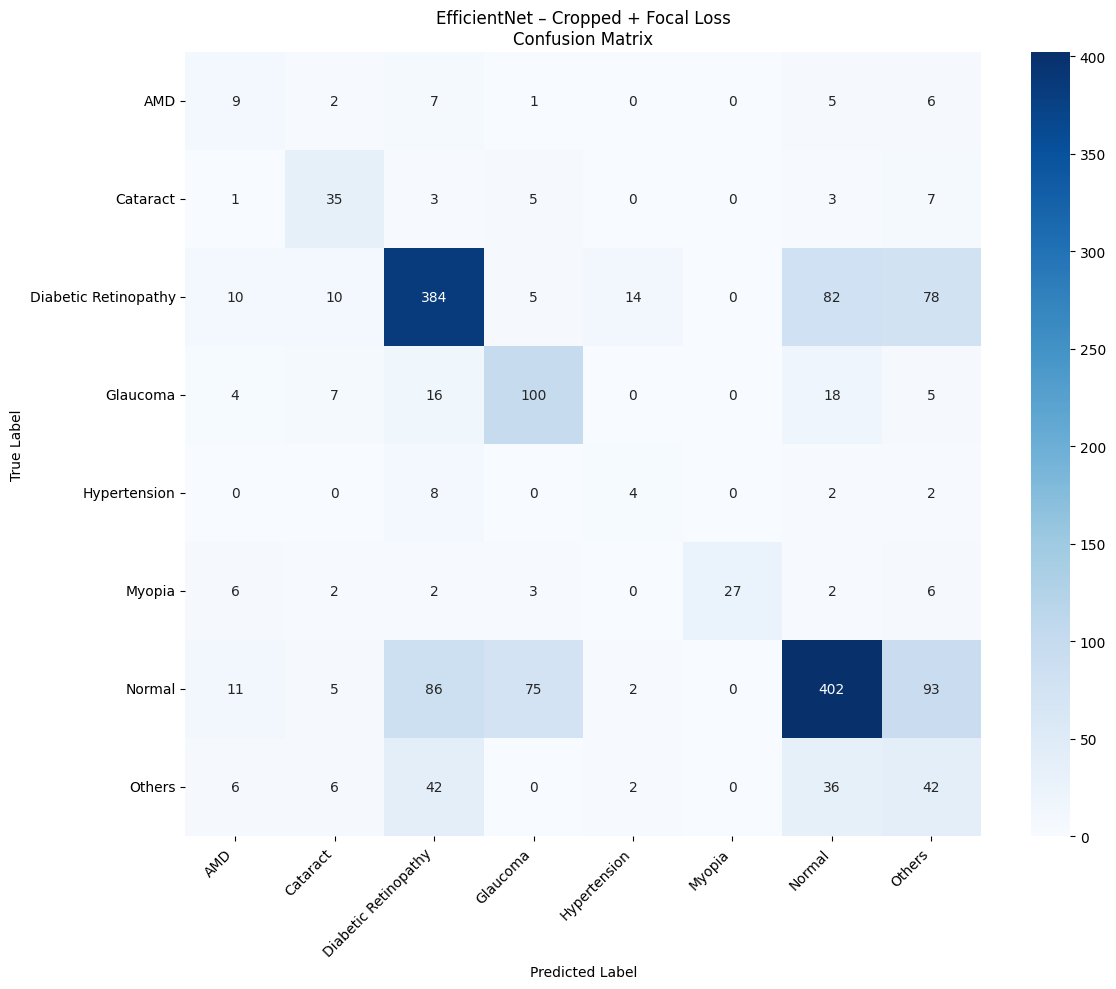

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# Predictions
y_test_pred_prob = transfer_crop.predict(test_crop)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNet – Cropped + Focal Loss\nConfusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [74]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred, target_names=class_names, digits=4))

                      precision    recall  f1-score   support

                 AMD     0.1915    0.3000    0.2338        30
            Cataract     0.5224    0.6481    0.5785        54
Diabetic Retinopathy     0.7007    0.6587    0.6790       583
            Glaucoma     0.5291    0.6667    0.5900       150
        Hypertension     0.1818    0.2500    0.2105        16
              Myopia     1.0000    0.5625    0.7200        48
              Normal     0.7309    0.5964    0.6569       674
              Others     0.1757    0.3134    0.2252       134

            accuracy                         0.5938      1689
           macro avg     0.5040    0.4995    0.4867      1689
        weighted avg     0.6447    0.5938    0.6119      1689



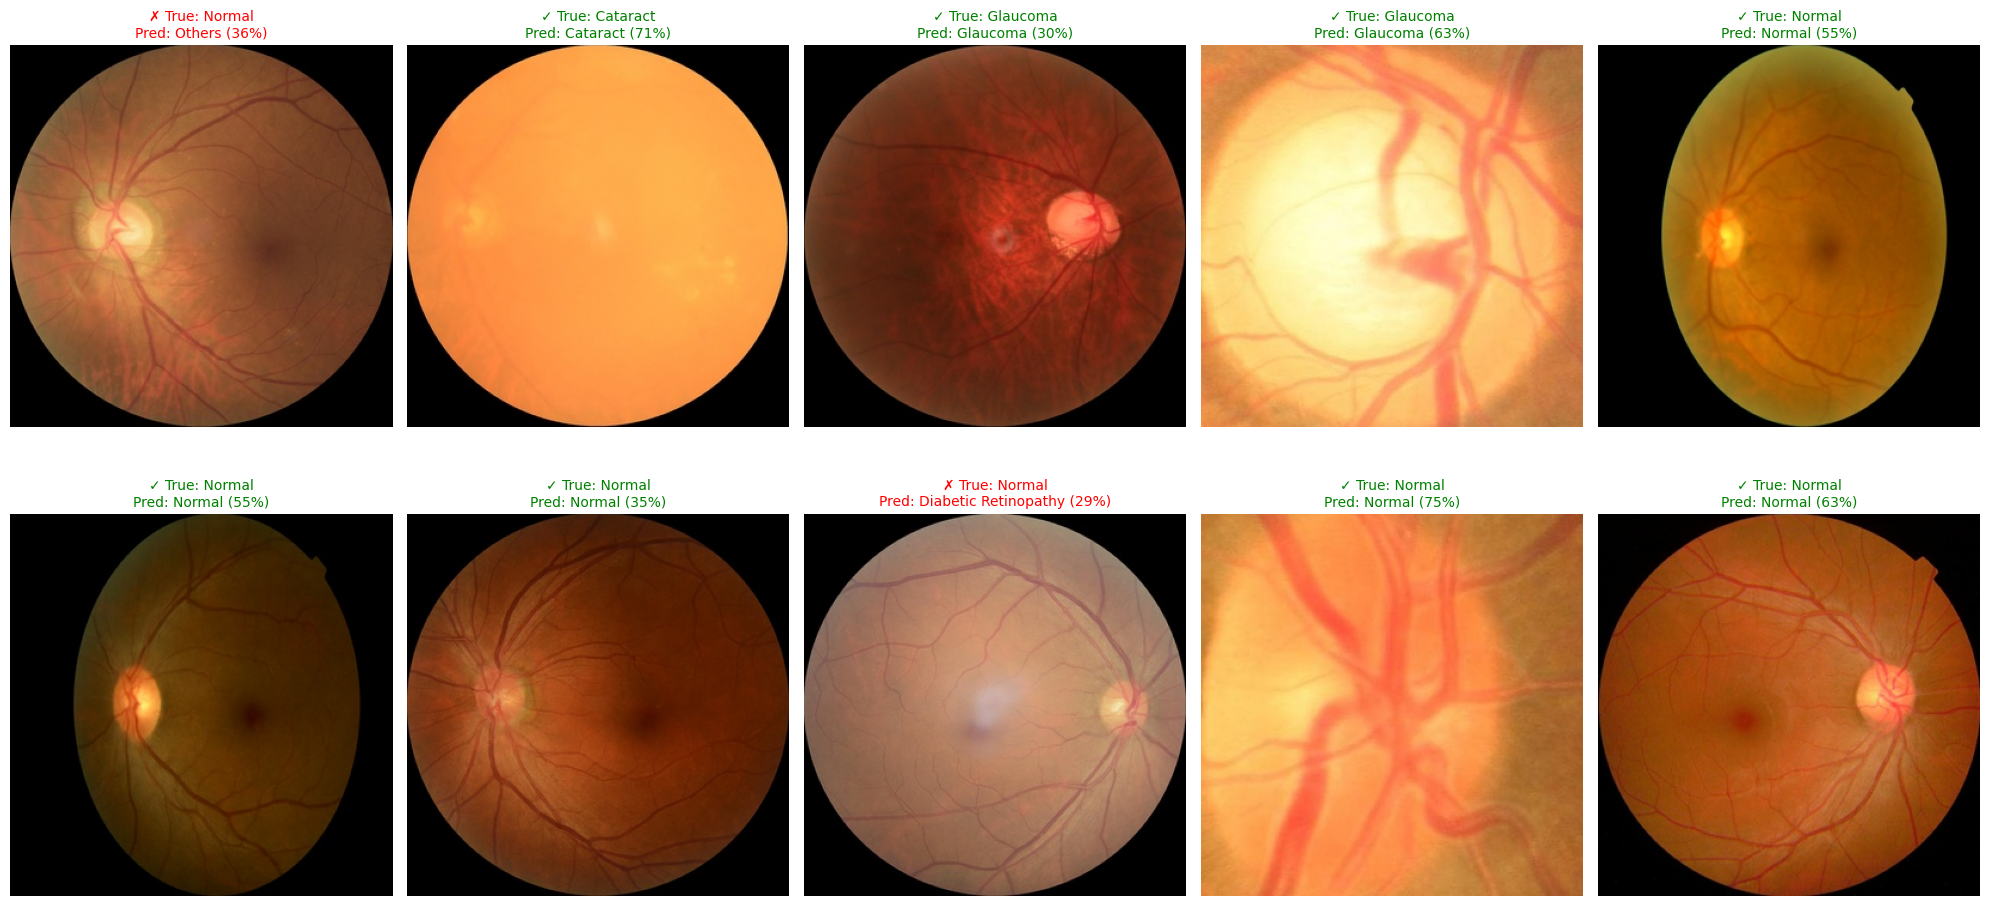


8/10 correct in this sample


In [72]:
import random

n = 10
sample_idx = random.sample(list(test_idx), n)
sample_df = df.loc[sample_idx].reset_index()

plt.figure(figsize=(20, 10))

for i, row in sample_df.iterrows():
    # load the same preprocessed image the model was trained on
    img = Image.open(row["crop_path"]).convert("RGB")
    img_array = np.expand_dims(np.array(img, dtype=np.float32), axis=0)

    # predict
    probs = transfer_crop.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_label = CLASSES[pred_idx]
    pred_confidence = probs[pred_idx] * 100

    true_label = row["unified_label"]
    is_correct = (pred_label == true_label)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

    color = "green" if is_correct else "red"
    mark = "✓" if is_correct else "✗"
    plt.title(
        f"{mark} True: {true_label}\nPred: {pred_label} ({pred_confidence:.0f}%)",
        color=color,
        fontsize=10
    )

plt.tight_layout()
plt.show()

correct_count = sum(
    CLASSES[np.argmax(transfer_crop.predict(
        np.expand_dims(np.array(Image.open(df.loc[i, "crop_path"]).convert("RGB"), dtype=np.float32), axis=0),
        verbose=0)[0])] == df.loc[i, "unified_label"]
    for i in sample_idx
)
print(f"\n{correct_count}/{n} correct in this sample")

Try Anomly / Normal

In [75]:
df["y_binary"] = (df["unified_label"] != "Normal").astype(int)  

print(df["y_binary"].value_counts())

y_binary
1    7141
0    4698
Name: count, dtype: int64


In [76]:
def make_dataset(dataframe, path_column, label_column="y", training=False):
    paths = dataframe[path_column].values
    labels = dataframe[label_column].values
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(len(dataframe), seed=SEED)
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        dataset = dataset.map(lambda x, y: (AUGMENTATION(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

In [77]:
def build_transfer_n(num_classes):
    base_model = EfficientNetB0(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs), base_model

# datasets
train_bin = make_dataset(df.loc[train_idx], "crop_path", label_column="y_binary", training=True)
val_bin   = make_dataset(df.loc[val_idx],   "crop_path", label_column="y_binary", training=False)
test_bin  = make_dataset(df.loc[test_idx],  "crop_path", label_column="y_binary", training=False)
y_val_bin  = df.loc[val_idx,  "y_binary"].values
y_test_bin = df.loc[test_idx, "y_binary"].values

# class weights (Normal ~4698 vs Anomaly ~7141 — fairly balanced already)
bin_counts = np.bincount(df.loc[train_idx, "y_binary"])
bin_weights = (bin_counts.sum() / (2 * bin_counts)) ** 0.5
BIN_CLASS_WEIGHT = {i: float(bin_weights[i]) for i in range(2)}

transfer_binary, base_binary = build_transfer_n(2)
transfer_binary.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                         loss="sparse_categorical_crossentropy", metrics=["accuracy"])
transfer_binary.fit(train_bin, validation_data=val_bin, epochs=8,
                     class_weight=BIN_CLASS_WEIGHT,
                     callbacks=make_callbacks(val_bin, y_val_bin, patience=4), verbose=1)

# fine-tune
base_binary.trainable = True
for layer in base_binary.layers[:-60]:
    layer.trainable = False
for layer in base_binary.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

transfer_binary.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                         loss="sparse_categorical_crossentropy", metrics=["accuracy"])
transfer_binary.fit(train_bin, validation_data=val_bin, epochs=20,
                     class_weight=BIN_CLASS_WEIGHT,
                     callbacks=make_callbacks(val_bin, y_val_bin, patience=3), verbose=1)

Epoch 1/8
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.6593 - loss: 0.6147 - val_macro_f1: 0.7242
265/265 ━━━━━━━━━━━━━━━━━━━━ 142s 452ms/step - accuracy: 0.6952 - loss: 0.5710 - val_accuracy: 0.7280 - val_loss: 0.5219 - val_macro_f1: 0.7242 - learning_rate: 0.0010
Epoch 2/8
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.7394 - loss: 0.5150 - val_macro_f1: 0.7359
265/265 ━━━━━━━━━━━━━━━━━━━━ 122s 425ms/step - accuracy: 0.7377 - loss: 0.5110 - val_accuracy: 0.7640 - val_loss: 0.4742 - val_macro_f1: 0.7359 - learning_rate: 0.0010
Epoch 3/8
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.7520 - loss: 0.4919 - val_macro_f1: 0.7530
265/265 ━━━━━━━━━━━━━━━━━━━━ 112s 422ms/step - accuracy: 0.7491 - loss: 0.4937 - val_accuracy: 0.7682 - val_loss: 0.4634 - val_macro_f1: 0.7530 - learning_rate: 0.0010
Epoch 4/8
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.7455 - loss: 0.4960 - val_macro_f1: 0.7555
265/265 ━━━━━━━━━━━━━━━━━━━━ 84s 316ms/step - accuracy: 

In [82]:
bin_preds = np.argmax(transfer_binary.predict(test_bin), axis=1)
print(classification_report(y_test_bin, bin_preds, target_names=["Normal", "Anomaly"], digits=4))

53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step
              precision    recall  f1-score   support

      Normal     0.7265    0.7211    0.7238       674
     Anomaly     0.8157    0.8197    0.8177      1015

    accuracy                         0.7803      1689
   macro avg     0.7711    0.7704    0.7707      1689
weighted avg     0.7801    0.7803    0.7802      1689



In [78]:
disease_df = df[df["unified_label"] != "Normal"].copy()

disease_encoder = LabelEncoder()
disease_df["y_disease"] = disease_encoder.fit_transform(disease_df["unified_label"])
DISEASE_CLASSES = disease_encoder.classes_
print("Disease classes:", DISEASE_CLASSES)

# reuse the SAME group-based split, just restricted to non-Normal rows
disease_train_idx = np.intersect1d(train_idx, disease_df.index)
disease_val_idx   = np.intersect1d(val_idx,   disease_df.index)
disease_test_idx  = np.intersect1d(test_idx,  disease_df.index)

train_dis = make_dataset(disease_df.loc[disease_train_idx], "crop_path", label_column="y_disease", training=True)
val_dis   = make_dataset(disease_df.loc[disease_val_idx],   "crop_path", label_column="y_disease", training=False)
test_dis  = make_dataset(disease_df.loc[disease_test_idx],  "crop_path", label_column="y_disease", training=False)
y_val_dis  = disease_df.loc[disease_val_idx,  "y_disease"].values
y_test_dis = disease_df.loc[disease_test_idx, "y_disease"].values

dis_counts = np.bincount(disease_df.loc[disease_train_idx, "y_disease"], minlength=len(DISEASE_CLASSES))
dis_weights = (dis_counts.sum() / (len(DISEASE_CLASSES) * dis_counts)) ** 0.5
DISEASE_CLASS_WEIGHT = {i: float(dis_weights[i]) for i in range(len(DISEASE_CLASSES))}

transfer_disease, base_disease = build_transfer_n(len(DISEASE_CLASSES))
transfer_disease.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                          loss="sparse_categorical_crossentropy", metrics=["accuracy"])
transfer_disease.fit(train_dis, validation_data=val_dis, epochs=8,
                      class_weight=DISEASE_CLASS_WEIGHT,
                      callbacks=make_callbacks(val_dis, y_val_dis, patience=4), verbose=1)

base_disease.trainable = True
for layer in base_disease.layers[:-60]:
    layer.trainable = False
for layer in base_disease.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

transfer_disease.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                          loss="sparse_categorical_crossentropy", metrics=["accuracy"])
transfer_disease.fit(train_dis, validation_data=val_dis, epochs=20,
                      class_weight=DISEASE_CLASS_WEIGHT,
                      callbacks=make_callbacks(val_dis, y_val_dis, patience=3), verbose=1)

Disease classes: ['AMD' 'Cataract' 'Diabetic Retinopathy' 'Glaucoma' 'Hypertension'
 'Myopia' 'Others']
Epoch 1/8
159/160 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.6084 - loss: 1.1968

2026-09-25 14:45:44.676905: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 14:45:44.818623: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 14:45:45.184018: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 14:45:45.326972: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 14:45:46.203626: E external/local_xla/xla/stream_

160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.6086 - loss: 1.1961

2026-09-25 14:46:10.931763: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 14:46:11.083750: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 14:46:11.505960: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 14:46:11.647727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 14:46:12.487638: E external/local_xla/xla/stream_

 - val_macro_f1: 0.5009
160/160 ━━━━━━━━━━━━━━━━━━━━ 126s 639ms/step - accuracy: 0.6338 - loss: 1.0886 - val_accuracy: 0.6380 - val_loss: 0.9593 - val_macro_f1: 0.5009 - learning_rate: 0.0010
Epoch 2/8
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.6567 - loss: 0.9137 - val_macro_f1: 0.5120
160/160 ━━━━━━━━━━━━━━━━━━━━ 52s 324ms/step - accuracy: 0.6634 - loss: 0.9108 - val_accuracy: 0.6360 - val_loss: 0.8930 - val_macro_f1: 0.5120 - learning_rate: 0.0010
Epoch 3/8
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.6758 - loss: 0.8592 - val_macro_f1: 0.4894
160/160 ━━━━━━━━━━━━━━━━━━━━ 52s 327ms/step - accuracy: 0.6665 - loss: 0.8584 - val_accuracy: 0.7221 - val_loss: 0.7804 - val_macro_f1: 0.4894 - learning_rate: 0.0010
Epoch 4/8
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.6704 - loss: 0.8468 - val_macro_f1: 0.5528
160/160 ━━━━━━━━━━━━━━━━━━━━ 55s 345ms/step - accuracy: 0.6718 - loss: 0.8270 - val_accuracy: 0.6967 - val_loss: 0.8311 - val_macro_f1: 0.5528 -

2026-09-25 14:54:16.248106: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 14:54:16.389174: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 14:54:16.531175: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 14:54:16.671888: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 14:54:16.953313: E external/local_xla/xla/stream_

160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6897 - loss: 0.7721 - val_macro_f1: 0.5821
160/160 ━━━━━━━━━━━━━━━━━━━━ 132s 637ms/step - accuracy: 0.6906 - loss: 0.7636 - val_accuracy: 0.7084 - val_loss: 0.7646 - val_macro_f1: 0.5821 - learning_rate: 1.0000e-05
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.6905 - loss: 0.7576 - val_macro_f1: 0.5741
160/160 ━━━━━━━━━━━━━━━━━━━━ 74s 461ms/step - accuracy: 0.6993 - loss: 0.7469 - val_accuracy: 0.7280 - val_loss: 0.7424 - val_macro_f1: 0.5741 - learning_rate: 1.0000e-05
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.6969 - loss: 0.7494 - val_macro_f1: 0.5931
160/160 ━━━━━━━━━━━━━━━━━━━━ 56s 347ms/step - accuracy: 0.6949 - loss: 0.7402 - val_accuracy: 0.7202 - val_loss: 0.7525 - val_macro_f1: 0.5931 - learning_rate: 1.0000e-05
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.7062 - loss: 0.7066 - val_macro_f1: 0.5779
160/160 ━━━━━━━━━━━━━━━━━━━━ 56s 347ms/step - accurac

In [79]:
dis_preds = np.argmax(transfer_disease.predict(test_dis), axis=1)
print(classification_report(y_test_dis, dis_preds, target_names=DISEASE_CLASSES, digits=4))

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

2026-09-25 15:08:44.204668: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 15:08:44.351114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 15:08:44.732171: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 15:08:44.874776: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 15:08:45.760587: E external/local_xla/xla/stream_

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 481ms/step
                      precision    recall  f1-score   support

                 AMD     0.4615    0.2000    0.2791        30
            Cataract     0.5067    0.7037    0.5891        54
Diabetic Retinopathy     0.7926    0.8456    0.8183       583
            Glaucoma     0.8780    0.7200    0.7912       150
        Hypertension     0.1667    0.1875    0.1765        16
              Myopia     0.9444    0.7083    0.8095        48
              Others     0.3516    0.3358    0.3435       134

            accuracy                         0.7163      1015
           macro avg     0.5859    0.5287    0.5439      1015
        weighted avg     0.7193    0.7163    0.7129      1015



In [80]:
def predict_pipeline(image_path, stage1_model, stage2_model, disease_classes):
    img = Image.open(image_path).convert("RGB")
    img_array = np.expand_dims(np.array(img, dtype=np.float32), axis=0)

    stage1_probs = stage1_model.predict(img_array, verbose=0)[0]
    if np.argmax(stage1_probs) == 0:  # predicted Normal
        return "Normal"

    stage2_probs = stage2_model.predict(img_array, verbose=0)[0]
    return disease_classes[np.argmax(stage2_probs)]

In [81]:
pipeline_preds = [
    predict_pipeline(df.loc[idx, "crop_path"], transfer_binary, transfer_disease, DISEASE_CLASSES)
    for idx in test_idx
]
true_labels = df.loc[test_idx, "unified_label"].values

print(classification_report(true_labels, pipeline_preds, digits=4))

                      precision    recall  f1-score   support

                 AMD     0.3750    0.2000    0.2609        30
            Cataract     0.4868    0.6852    0.5692        54
Diabetic Retinopathy     0.6564    0.7307    0.6916       583
            Glaucoma     0.7097    0.5867    0.6423       150
        Hypertension     0.1579    0.1875    0.1714        16
              Myopia     0.8947    0.7083    0.7907        48
              Normal     0.7277    0.7136    0.7206       674
              Others     0.2075    0.1642    0.1833       134

            accuracy                         0.6495      1689
           macro avg     0.5270    0.4970    0.5038      1689
        weighted avg     0.6456    0.6495    0.6448      1689

